In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('../dataset/predict_prices_dataset.csv')
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,99,Manual,15735,Petrol,150,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi


## Experiment 1 — Raw baseline (numeric features only)

Train Linear Regression on numeric columns only. No cleaning, no encoding, no transformations. This is the reference point.

In [16]:
# Keep only numeric features, drop the target from X
X = df.select_dtypes(include='number').drop(columns=['price'])
y = df['price']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train and predict
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

MAE:  3327.38
RMSE: 5067.32
R²:   0.710


## Experiment 2 — Add categorical features (encoding)

Include categorical columns via encoding:
- `transmission`, `fuelType`, `Make` → **one-hot encoding** (few categories)
- `model` → **target encoding** (high cardinality — one-hot would create too many columns)

Target encoding is computed **only from the train set** to avoid data leakage.

In [17]:
# One-hot encode low-cardinality categorical columns
df_encoded = pd.get_dummies(df, columns=['transmission', 'fuelType', 'Make'], drop_first=True)

# Split first so target encoding is computed only from train (no data leakage)
train_df, test_df = train_test_split(df_encoded, test_size=0.2, random_state=42)

# Target encoding for 'model': replace each model with the mean price of that model in train
model_means = train_df.groupby('model')['price'].mean()
train_df['model_encoded'] = train_df['model'].map(model_means)
test_df['model_encoded'] = test_df['model'].map(model_means)
# Fallback for models that appear only in test (unseen in train)
test_df['model_encoded'] = test_df['model_encoded'].fillna(model_means.mean())

# Separate features from target, drop the raw 'model' text column
X_train = train_df.drop(columns=['price', 'model'])
X_test = test_df.drop(columns=['price', 'model'])
y_train = train_df['price']
y_test = test_df['price']

# Train and evaluate
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"MAE:  {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

MAE:  2220.58
RMSE: 3476.22
R²:   0.864


## Experiment 3 — Remove outliers

Filter out data errors and edge cases that can distort the regression line:
- Price < £500 (likely data entry errors)
- MPG > 400 (physically impossible)
- Year < 2001 (vintage cars follow a different market logic; also < 0.05% of the dataset)

In [18]:
# Apply outlier filters on the already-encoded dataframe
df_clean = df_encoded[df_encoded['price'] >= 500]
df_clean = df_clean[df_clean['mpg'] <= 400]
df_clean = df_clean[df_clean['year'] >= 2001]

print(f"Before: {len(df_encoded)} rows")
print(f"After:  {len(df_clean)} rows")
print(f"Removed: {len(df_encoded) - len(df_clean)} rows")

# Same encoding pipeline as Experiment 2, but on cleaned data
train_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=42)

model_means = train_df.groupby('model')['price'].mean()
train_df['model_encoded'] = train_df['model'].map(model_means)
test_df['model_encoded'] = test_df['model'].map(model_means)
test_df['model_encoded'] = test_df['model_encoded'].fillna(model_means.mean())

X_train = train_df.drop(columns=['price', 'model'])
X_test = test_df.drop(columns=['price', 'model'])
y_train = train_df['price']
y_test = test_df['price']

# Train and evaluate
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"\nMAE:  {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

Before: 72435 rows
After:  72371 rows
Removed: 64 rows

MAE:  2207.92
RMSE: 3353.45
R²:   0.873


## Experiment 4 — Log transform on price

The price distribution is right-skewed. Applying `log1p` to the target should make it more symmetric (closer to normal), which theoretically helps Linear Regression. We train in log space and convert predictions back with `expm1` before computing metrics.

In [19]:
# Rebuild the same clean pipeline as Experiment 3
train_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=42)

model_means = train_df.groupby('model')['price'].mean()
train_df['model_encoded'] = train_df['model'].map(model_means)
test_df['model_encoded'] = test_df['model'].map(model_means)
test_df['model_encoded'] = test_df['model_encoded'].fillna(model_means.mean())

X_train = train_df.drop(columns=['price', 'model'])
X_test = test_df.drop(columns=['price', 'model'])

# Log-transform the target (train on log(price))
y_train_log = np.log1p(train_df['price'])
y_test = test_df['price']  # keep real prices for evaluation

# Train and predict in log space
model = LinearRegression()
model.fit(X_train, y_train_log)
y_pred_log = model.predict(X_test)

# Convert predictions back to real prices with expm1 (inverse of log1p)
y_pred = np.expm1(y_pred_log)

print(f"MAE:  {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

MAE:  2040.33
RMSE: 4311.66
R²:   0.790


## Experiment 5 — Log on both price and mileage

The mileage-vs-price relationship is exponential decay. Applying `log1p` to mileage as well should linearize the relationship so Linear Regression can capture it better.

In [20]:
# Rebuild the same clean pipeline
train_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=42)

model_means = train_df.groupby('model')['price'].mean()
train_df['model_encoded'] = train_df['model'].map(model_means)
test_df['model_encoded'] = test_df['model'].map(model_means)
test_df['model_encoded'] = test_df['model_encoded'].fillna(model_means.mean())

X_train = train_df.drop(columns=['price', 'model'])
X_test = test_df.drop(columns=['price', 'model'])

# Log-transform mileage feature
X_train['mileage'] = np.log1p(X_train['mileage'])
X_test['mileage'] = np.log1p(X_test['mileage'])

# Log-transform target
y_train_log = np.log1p(train_df['price'])
y_test = test_df['price']

# Train and predict in log space, then convert back
model = LinearRegression()
model.fit(X_train, y_train_log)
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)

print(f"MAE:  {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

MAE:  2134.89
RMSE: 4399.22
R²:   0.781


## Experiment 6 — Standardization

In [ ]:
# Rebuild the clean pipeline (no log)
train_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=42)

model_means = train_df.groupby('model')['price'].mean()
train_df['model_encoded'] = train_df['model'].map(model_means)
test_df['model_encoded'] = test_df['model'].map(model_means)
test_df['model_encoded'] = test_df['model_encoded'].fillna(model_means.mean())

X_train = train_df.drop(columns=['price', 'model'])
X_test = test_df.drop(columns=['price', 'model'])
y_train = train_df['price']
y_test = test_df['price']

# Apply StandardScaler: fit on train only (avoid data leakage), transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train and evaluate
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f"MAE:  {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

## Residual Analysis — Proof of Non-Linearity

Residuals = `actual price - predicted price`. If Linear Regression captures the true relationship well, residuals should be **randomly scattered around 0**. Any visible pattern (curve, funnel, U-shape) is proof that the model is missing something — usually non-linearity.

We plot residuals from our best model (Experiment 3, R² = 0.873) against predicted prices.

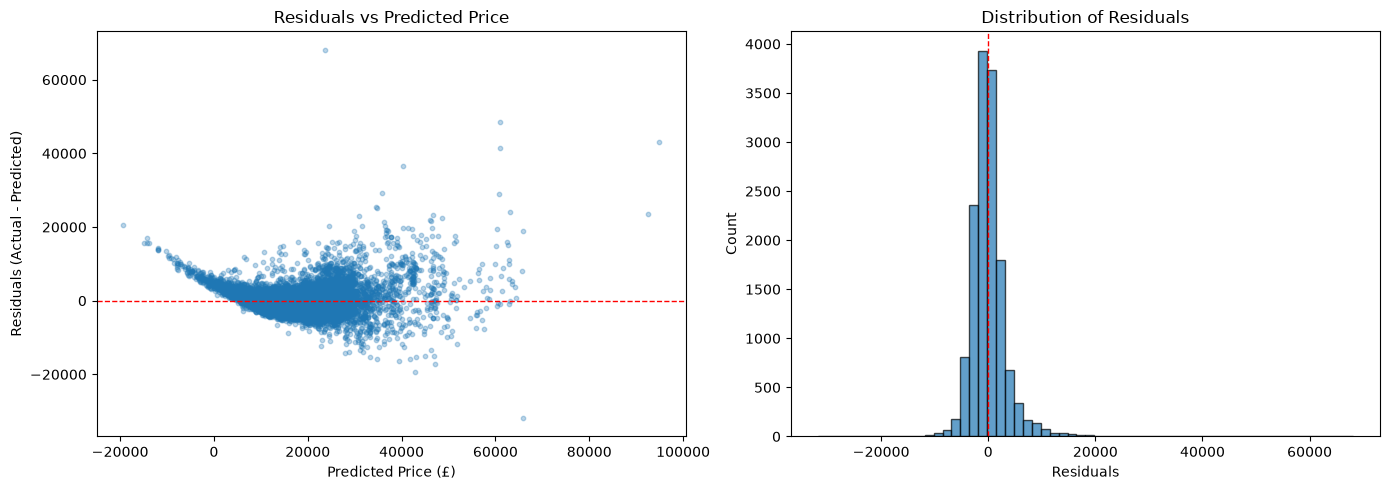

Mean of residuals:   26.96  (should be close to 0)
Std of residuals:    3353.45
Min / Max residuals: -31872.96 / 68139.93


In [21]:
import matplotlib.pyplot as plt

# Rebuild best model (Experiment 3 — clean data, no log)
train_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=42)

model_means = train_df.groupby('model')['price'].mean()
train_df['model_encoded'] = train_df['model'].map(model_means)
test_df['model_encoded'] = test_df['model'].map(model_means)
test_df['model_encoded'] = test_df['model_encoded'].fillna(model_means.mean())

X_train = train_df.drop(columns=['price', 'model'])
X_test = test_df.drop(columns=['price', 'model'])
y_train = train_df['price']
y_test = test_df['price']

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Compute residuals
residuals = y_test - y_pred

# Plot: residuals vs predicted + histogram of residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: residuals scatter — should be random around 0
axes[0].scatter(y_pred, residuals, alpha=0.3, s=10)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Price (£)')
axes[0].set_ylabel('Residuals (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted Price')

# Right: residuals distribution — should be roughly normal, centered on 0
axes[1].hist(residuals, bins=60, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

print(f"Mean of residuals:   {residuals.mean():.2f}  (should be close to 0)")
print(f"Std of residuals:    {residuals.std():.2f}")
print(f"Min / Max residuals: {residuals.min():.2f} / {residuals.max():.2f}")

### Residuals with log-transform — does log fix it?

Let's rebuild residuals from Experiment 4 (log on price) and compare. If log truly solved the non-linearity, the curve pattern should disappear.

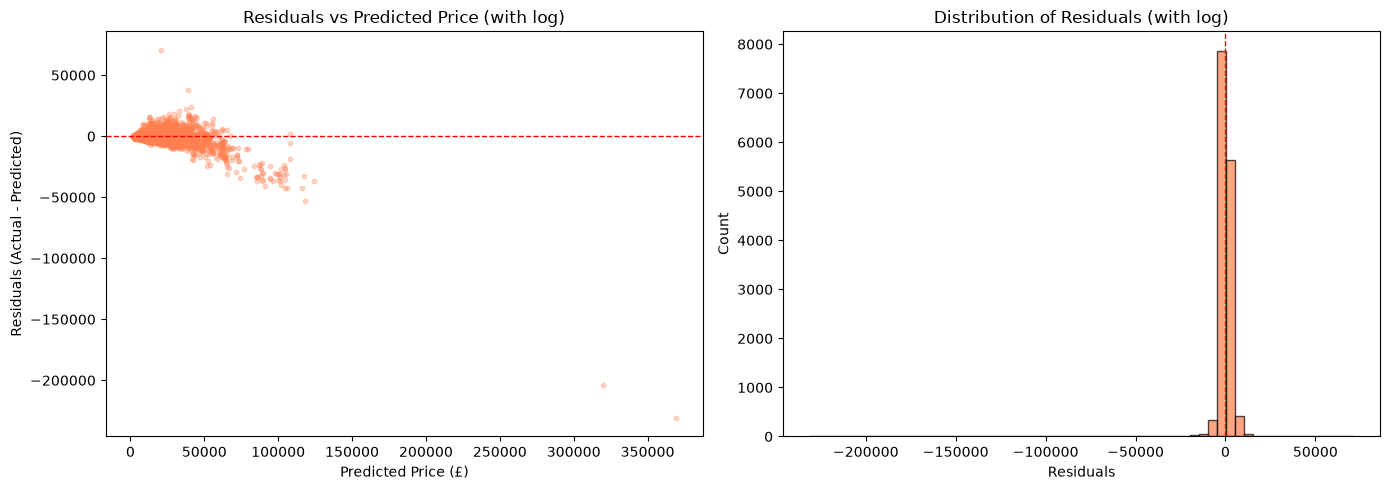

Mean of residuals:   73.94
Std of residuals:    4311.18
Min / Max residuals: -230953.21 / 70843.32


In [22]:
# Rebuild Experiment 4 (log price)
train_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=42)

model_means = train_df.groupby('model')['price'].mean()
train_df['model_encoded'] = train_df['model'].map(model_means)
test_df['model_encoded'] = test_df['model'].map(model_means)
test_df['model_encoded'] = test_df['model_encoded'].fillna(model_means.mean())

X_train = train_df.drop(columns=['price', 'model'])
X_test = test_df.drop(columns=['price', 'model'])

y_train_log = np.log1p(train_df['price'])
y_test = test_df['price']

model = LinearRegression()
model.fit(X_train, y_train_log)
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)

# Residuals in REAL price space (after converting back from log)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred, residuals, alpha=0.3, s=10, color='coral')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Price (£)')
axes[0].set_ylabel('Residuals (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted Price (with log)')

axes[1].hist(residuals, bins=60, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals (with log)')

plt.tight_layout()
plt.show()

print(f"Mean of residuals:   {residuals.mean():.2f}")
print(f"Std of residuals:    {residuals.std():.2f}")
print(f"Min / Max residuals: {residuals.min():.2f} / {residuals.max():.2f}")

### Residual analysis — what the plots tell us

#### Without log (Experiment 3, R² = 0.873)

- **Clear U-shape curve**: for low predicted prices (£0–£10k) residuals are mostly **positive** (model underestimates), for mid prices (£15k–£25k) they drop below 0 (model overestimates), then rise again for expensive cars. This curved pattern is the classic signature of **non-linearity** — a straight line can't follow the true relationship.
- **Negative predicted prices** (down to -£20,000): the model predicts impossible values for cheap cars, extrapolating the line into negative territory.
- **Funnel shape**: residual spread grows with predicted price — errors on expensive cars are much larger (±£40k–£60k) than on cheap ones (±£5k). This is heteroscedasticity, another sign the linear model is a poor fit.

#### With log on price (Experiment 4, R² = 0.790)

- **Bulk of predictions look tighter around 0** — that's why MAE improved (2,040 vs 2,207). The model is more accurate on average for typical cars.
- **BUT catastrophic outliers appeared**: a few points predicting £300k–£370k for cars that actually cost £70k–£100k, producing residuals of -£200,000+.
- **Why this happens**: when we convert predictions back with `expm1()`, small errors in log space get **exponentially amplified**. An error of 2 in log space becomes a factor of ~7.4× in the real price. That's why RMSE ballooned from 3,353 to 4,311 — a handful of extreme errors dominate the score.
- **The curvature is still there** — log didn't fix the underlying non-linear relationship, it just redistributed the errors differently.

#### Why log didn't work here — theory vs practice

**Textbook theory** says log-transform helps Linear Regression when:
- The target is right-skewed (which ours is)
- Relationships between features and target are **purely exponential**
- Residuals are heteroscedastic (variance grows with prediction)

In theory, log makes the target more normally distributed, linearizes exponential relationships, and stabilizes variance — all three conditions Linear Regression assumes. That's why it's taught as a standard fix for skewed regression problems.

**Reality on this dataset** — the relationships are mixed:
- `mileage → price` has an exponential component → log helps *there*.
- `year → price` is roughly linear → log distorts it.
- `Make → price` is categorical (jumps, not curves) → log is irrelevant.
- `engineSize → price` depends heavily on brand → not a clean exponential.

By forcing log on the target, we tell the model "all relationships are exponential" — but they aren't. For the non-exponential ones, log **distorts** them instead of helping. Combined with the amplification problem from `expm1()`, the net effect is worse performance.

#### Conclusion

Log-transform is a **hypothesis**, not a guaranteed fix. The textbook says it helps when relationships are exponential — but you can't know that without testing. On this dataset the residual plots make the failure visible: the U-shape curve persists even with log, just repositioned, proving Linear Regression itself is the limitation. The right next step is a model that natively handles non-linear and mixed relationships — Random Forest or XGBoost.

# Conclusions

## Results summary

| # | Experiment | MAE | RMSE | R² |
|---|---|---|---|---|
| 1 | Raw baseline (numeric only) | 3,327 | 5,067 | 0.710 |
| 2 | + Categorical encoding | 2,220 | 3,476 | 0.864 |
| 3 | + Outlier removal | 2,207 | 3,353 | **0.873** |
| 4 | + Log price | 2,040 | 4,311 | 0.790 |
| 5 | + Log price + Log mileage | 2,134 | 4,399 | 0.781 |
| 6 | + Standardization (no log) | 2,207 | 3,353 | 0.873 |

## Key takeaways

- **Categorical encoding was the biggest win** (+0.154 in R²). Brand, model, transmission and fuel type carry a lot of predictive signal — dropping them costs a lot.
- **Outlier removal helped slightly** (+0.009). Only 64 rows were filtered (<0.1% of the dataset), so the impact was small but real: RMSE dropped, meaning fewer catastrophic errors on extreme values.
- **Log transform hurt performance** on this dataset. In theory it should help with skewed distributions, but the relationships here aren't purely exponential — forcing a log shape distorts them. When converting back with `expm1`, small errors in log space blow up into large errors in real prices, which is why RMSE and R² got worse.
- **Standardization changed nothing for R²**, as expected for Linear Regression (it only rescales coefficients). It would matter for SVM, KNN, or Neural Networks.